In [ ]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

1.

In [ ]:
from sklearn.linear_model import Lasso

2.

In [ ]:
crop_df = pd.read_csv('6_crop_yield_prediction.csv')

crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   annual_rainfall_mm        877 non-null    float64
 1   avg_temp                  879 non-null    float64
 2   sunshine_hours            870 non-null    float64
 3   soil_type                 875 non-null    object 
 4   soil_ph                   875 non-null    float64
 5   fertilizer_type           878 non-null    object 
 6   nitrogen_concentration    876 non-null    float64
 7   phosphorus_concentration  873 non-null    float64
 8   potassium_concentration   877 non-null    float64
 9   yield_kg_per_ha           900 non-null    float64
dtypes: float64(8), object(2)
memory usage: 70.4+ KB


In [ ]:
답안02 = 'avg_temp'

3.

<Axes: xlabel='yield_kg_per_ha', ylabel='Count'>

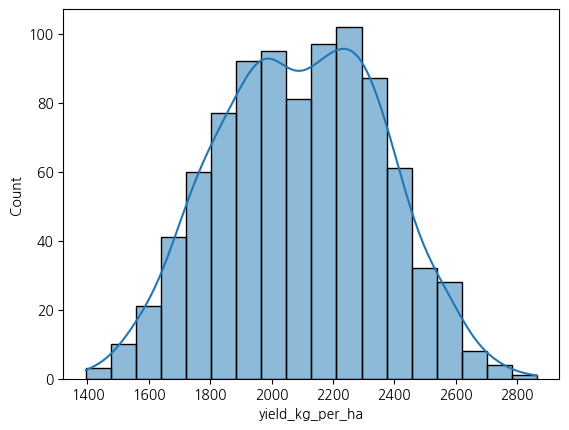

In [ ]:
sns.histplot(data=crop_df, x='yield_kg_per_ha', kde=True)

4.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request

# 1. 인터넷에서 나눔고딕 폰트 파일을 현재 폴더로 직접 다운로드
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
urllib.request.urlretrieve(font_url, "my_nanum_font.ttf")

# 2. 다운로드한 폰트 파일의 경로 지정 및 이름 속성 가져오기
fe = fm.FontEntry(fname="my_nanum_font.ttf", name="MyNanum")
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib 폰트 리스트 맨 앞에 강제 주입

# 3. 주입한 폰트 이름으로 전역 설정 변경 (마이너스 깨짐 방지도 함께)
plt.rc('font', family='MyNanum')
plt.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='soil_type', ylabel='yield_kg_per_ha'>

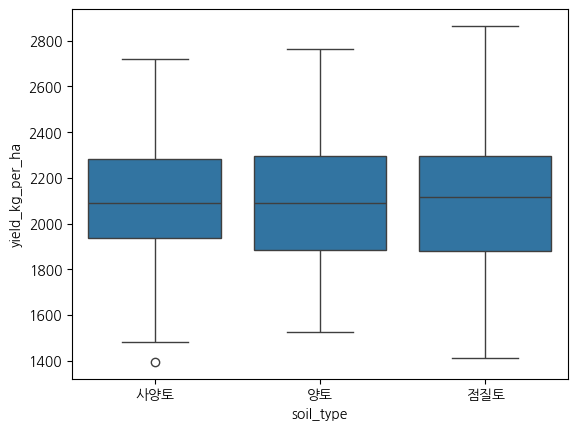

In [ ]:
sns.boxplot(data=crop_df, x='soil_type', y='yield_kg_per_ha')

In [ ]:
답안04 = '점질토'

5.

In [ ]:
crop_df.groupby(['fertilizer_type'])[['nitrogen_concentration', 'phosphorus_concentration', 'potassium_concentration']].mean()

,nitrogen_concentration,phosphorus_concentration,potassium_concentration
fertilizer_type,,,
복합,54.483378,27.914865,27.644434
인,52.917913,28.678341,28.077067
질소,53.118804,27.855561,27.622500
칼륨,54.444055,25.580329,26.975514


6.

In [ ]:
crop_pre = crop_df.copy()

crop_pre['avg_temp'].fillna(crop_pre['avg_temp'].mean(), inplace=True)
crop_pre['sunshine_hours'].fillna(crop_pre['sunshine_hours'].mean(), inplace=True)
crop_pre['annual_rainfall_mm'].fillna(crop_pre['annual_rainfall_mm'].mean(), inplace=True)
crop_pre['soil_ph'].fillna(crop_pre['soil_ph'].mean(), inplace=True)
crop_pre['nitrogen_concentration'].fillna(crop_pre['nitrogen_concentration'].mean(), inplace=True)
crop_pre['phosphorus_concentration'].fillna(crop_pre['phosphorus_concentration'].mean(), inplace=True)
crop_pre['potassium_concentration'].fillna(crop_pre['potassium_concentration'].mean(), inplace=True)

/tmp/ipykernel_5051/2233796359.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  crop_pre['avg_temp'].fillna(crop_pre['avg_temp'].mean(), inplace=True)
/tmp/ipykernel_5051/2233796359.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

7.

In [ ]:
crop_pre = pd.get_dummies(data=crop_pre, columns=['fertilizer_type'])

le = LabelEncoder()

crop_pre['soil_type'] = le.fit_transform(crop_pre['soil_type'])

8.

In [ ]:
crop_pre['nitro_potassium_ratio'] = np.where(crop_pre['potassium_concentration']==0, 0, crop_pre['nitrogen_concentration'] / crop_pre['potassium_concentration'])

9.

In [ ]:
X = crop_pre.drop(columns=['yield_kg_per_ha'])
y = crop_pre['yield_kg_per_ha']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=2024)

print(X_train.shape, X_valid.shape)
print(y_train.shape, y_valid.shape)

(720, 13) (180, 13)
(720,) (180,)


10.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

11.

In [ ]:
model_lasso = Lasso(alpha=0.5, random_state=2024)

model_lasso.fit(X_train_scaled, y_train)

lasso_pred = model_lasso.predict(X_valid_scaled)

12.

In [ ]:
model_rf = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=2024)

model_rf.fit(X_train_scaled, y_train)

rf_pred = model_rf.predict(X_valid_scaled)

13.

In [ ]:
print('Lasso')
print('MAE', mean_absolute_error(y_valid, lasso_pred))
print('R2', r2_score(y_valid, lasso_pred))

print("RF")
print("MAE", mean_absolute_error(y_valid, rf_pred))
print("R2", r2_score(y_valid, rf_pred))

Lasso
MAE 90.40206850033798
R2 0.7859797345448005
RF
MAE 92.4057852030709
R2 0.7790820506959394


14.

In [ ]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_valid_scaled, y_valid))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 4429814.0000 - val_loss: 4536486.5000
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4424610.0000 - val_loss: 4530291.0000
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4417077.5000 - val_loss: 4520852.5000
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4405553.0000 - val_loss: 4506656.5000
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4388776.0000 - val_loss: 4486354.5000
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4365543.0000 - val_loss: 4459363.0000
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4334922.5000 - val_loss: 4423889.5000
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4295011.0000 - val_loss: 4379405.5000
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4245359.5000 - val_loss: 4323914.0000
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4184172.5000 - val_loss: 4256216.0000
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_crop_data = np.array([[1500, 20.0, 2500.0, 1, 6.5, 35.0, 30.0, 40.0, 1, 0, 0, 0, 0.875]])

In [ ]:
new_crop_data_scaled = scaler.transform(new_crop_data)

predicted_yield_dl = model.predict(new_crop_data_scaled)

print(predicted_yield_dl)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
[[2372.9744]]
